In [1]:
!pip install diffusers transformers accelerate torch safetensors

In [2]:
import torch
from diffusers import StableDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

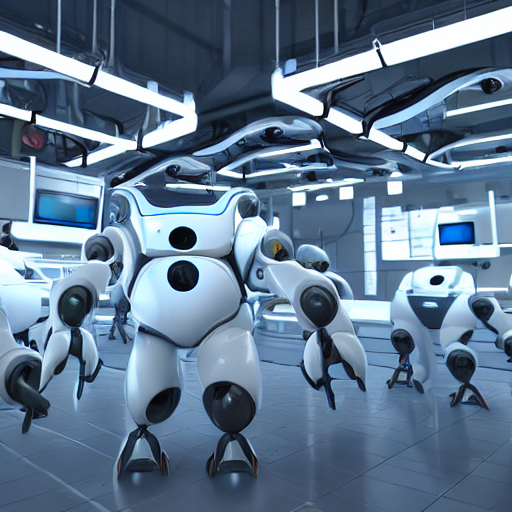

  0%|          | 0/50 [00:00<?, ?it/s]

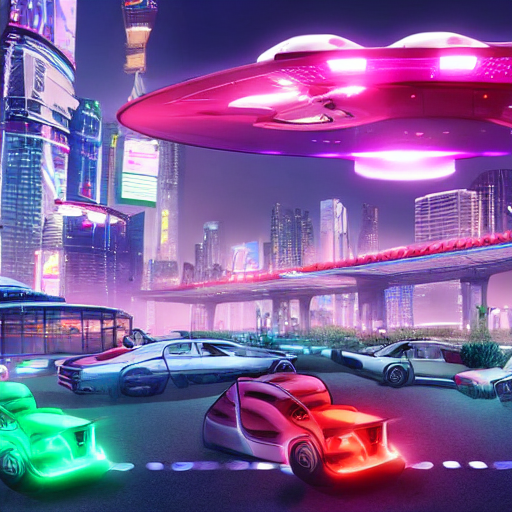

  0%|          | 0/50 [00:00<?, ?it/s]

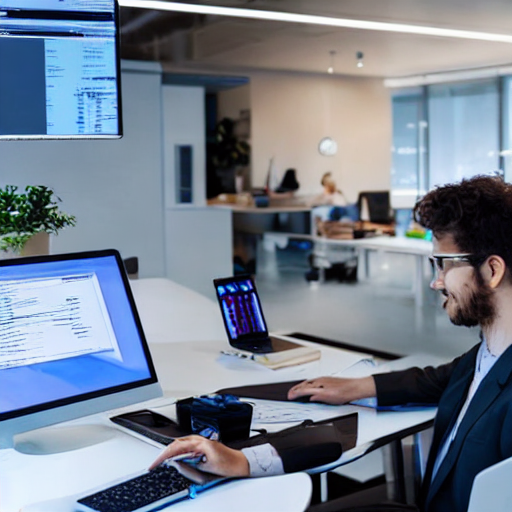

  0%|          | 0/50 [00:00<?, ?it/s]

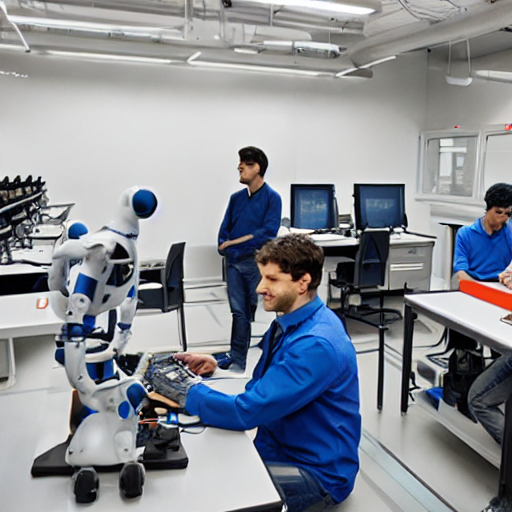

In [4]:
prompts = [
    "a futuristic AI laboratory with robots working, ultra realistic, 4k",
    "a smart city with flying cars and neon lights, cyberpunk style",
    "a humanoid robot coding on a computer in a modern office",
    "an advanced robotics lab with engineers and AI machines"
]

for i, prompt in enumerate(prompts):
    image = pipe(prompt).images[0]
    image.save(f"image_{i}.png")
    display(image)

In [5]:
!ls

image_0.png  image_1.png  image_2.png  image_3.png  sample_data


In [6]:
import os

os.makedirs("AI-Image-Generation-StableDiffusion/generated_images", exist_ok=True)

In [7]:
import shutil
import os

for file in os.listdir():
    if file.endswith(".png"):
        shutil.move(file, "AI-Image-Generation-StableDiffusion/generated_images/" + file)

In [8]:
!ls -R AI-Image-Generation-StableDiffusion

AI-Image-Generation-StableDiffusion:
generated_images

AI-Image-Generation-StableDiffusion/generated_images:
image_0.png  image_1.png  image_2.png  image_3.png


In [9]:
!zip -r project.zip AI-Image-Generation-StableDiffusion

  adding: AI-Image-Generation-StableDiffusion/ (stored 0%)
  adding: AI-Image-Generation-StableDiffusion/generated_images/ (stored 0%)
  adding: AI-Image-Generation-StableDiffusion/generated_images/image_3.png (deflated 0%)
  adding: AI-Image-Generation-StableDiffusion/generated_images/image_2.png (deflated 0%)
  adding: AI-Image-Generation-StableDiffusion/generated_images/image_0.png (deflated 0%)
  adding: AI-Image-Generation-StableDiffusion/generated_images/image_1.png (deflated 0%)


In [10]:
from google.colab import files
files.download("project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>